      clientid           x           y
0            1  622.771572  164.857623
1            2  416.357298  630.193634
2            3  292.735020  567.333231
3            4  737.211288  166.225676
4            5  540.475375  682.912298
...        ...         ...         ...
5951      5952  832.857394  616.861410
5952      5953  242.734500  490.325092
5953      5954  108.690847  758.833921
5954      5955  803.251074  430.740623
5955      5956  481.343899  285.910055

[5956 rows x 3 columns]


<Axes: xlabel='x', ylabel='y'>

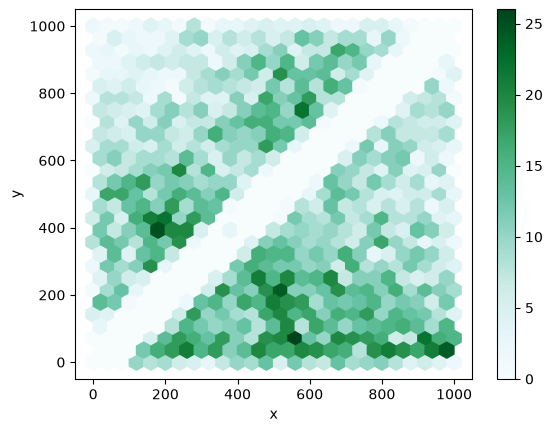

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

df = pd.read_csv('drone_cust_locations.csv', sep=';')
print(df)

X = df.drop(columns='clientid')

df.plot.hexbin(x="x", y="y", gridsize=25)


Darker areas means more customers, light areas have less customers.  
x - The x coordinate of the customer's location, when plotted into a 2D plane  
y - The y coordinate of the customer's location, when plotted into a 2D plane

[[702.21311616 211.32734145]
 [198.53635396 382.88575615]
 [548.00601882 787.2438163 ]]


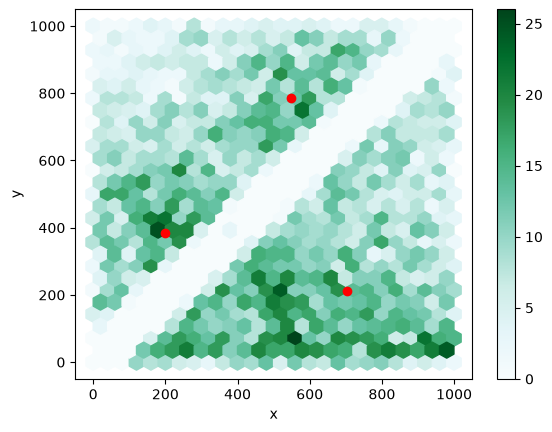

In [154]:
from sklearn.cluster import KMeans

model = KMeans(init='random', n_clusters=3, random_state=69)

start_1 = time.perf_counter()
model.fit(X)
end_1 = time.perf_counter()

plot = X.plot.hexbin(x="x", y="y", gridsize=25);

centers = model.cluster_centers_
print(centers)
plot.scatter(centers[:, 0],centers[:, 1],color="red")
plt.show()

In [155]:
#new df with new column with nearest center of current row as value

X_2 = X.copy()
X_2["depot"] = model.labels_
X_2["depot"] = X_2["depot"].astype("category")

print(X_2.head(10))

            x           y depot
0  622.771572  164.857623     0
1  416.357298  630.193634     2
2  292.735020  567.333231     1
3  737.211288  166.225676     0
4  540.475375  682.912298     2
5  535.469492  318.439661     0
6  640.380050  870.833221     2
7  235.772075  359.048203     1
8  481.896884  661.491838     2
9  730.032789  312.177817     0


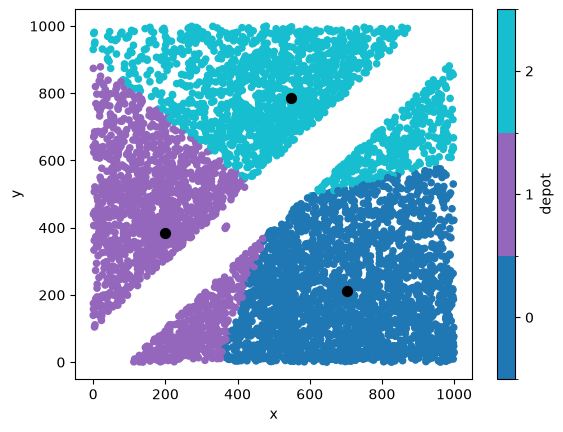

In [156]:
plot_2 = X_2.plot.scatter(x="x", y="y", c="depot",cmap="tab10", s=20);
plot_2.scatter(centers[:, 0],centers[:, 1],color="black",s=50)
plt.show()

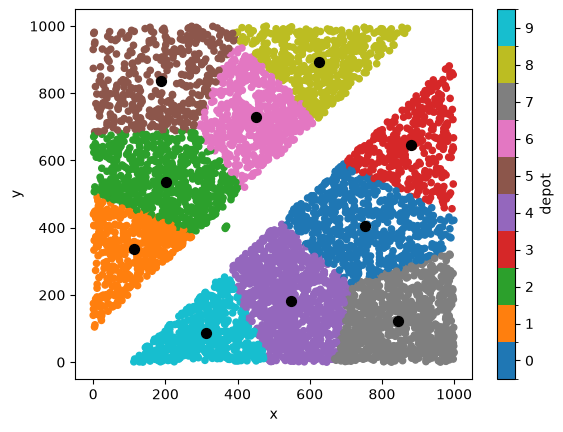

model 1: 43.288 ms | model 2: 52.822 ms


In [157]:
model_2 = KMeans(init='random', n_clusters=10, random_state=69)

start_2 = time.perf_counter()
model_2.fit(X)
end_2 = time.perf_counter()

X_3 = X.copy()
X_3["depot"] = model_2.labels_
X_3["depot"] = X_3["depot"].astype("category")

plot_3 = X_3.plot.scatter(x="x", y="y", c="depot",cmap="tab10", s=20);
plot_3.scatter(centers_2[:, 0],centers_2[:, 1],color="black",s=50)
plt.show()

print(f"model 1: {(end_1 - start_1) * 1000:.3f} ms | model 2: {(end_2 - start_2) * 1000:.3f} ms")

no significant difference in computation time

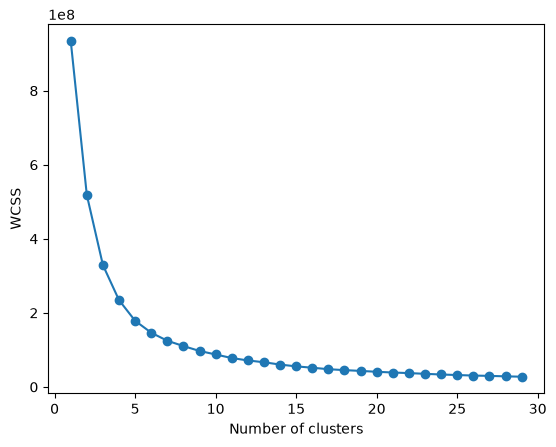

In [158]:
wcss = []
for i in range(1,30):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(X)
    wcss.append(model.inertia_)
    
plt.plot(range(1,30), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

5956
